In [6]:
import os
import shutil
import random
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
target_base = "catVsdog"
if os.path.exists(target_base):
    shutil.rmtree(target_base)
    print("Delete folder successfully..!")

Delete folder successfully..!


In [8]:
random.seed(42)

source_base = r"D:\dataset"          
target_base = r"catVsdog"          

num_train = 1000
num_val = 500
num_test = 500
total_needed = num_train + num_val + num_test    

classes = {
    "Cat": "cats",
    "Dog": "dogs"
}

all_indices = list(range(12500))  

for class_name, folder_name in classes.items():
    src_dir = os.path.join(source_base, class_name)
    
    selected = random.sample(all_indices, total_needed)
    
    train_idx = selected[:num_train]
    val_idx = selected[num_train:num_train + num_val]
    test_idx = selected[num_train + num_val:]
    
    splits = {
        "train": train_idx,
        "validation": val_idx,
        "test": test_idx
    }
    
    for split, indices in splits.items():
        dest_dir = os.path.join(target_base, split, folder_name)
        os.makedirs(dest_dir, exist_ok=True)
        
        for i in indices:
            src_file = os.path.join(src_dir, f"{i}.jpg")
            dest_file = os.path.join(dest_dir, f"{i}.jpg")
            shutil.copy2(src_file, dest_file)  
    
    print(f"Successfully {class_name} ")

print("Well done!")

Successfully Cat 
Successfully Dog 
Well done!


In [9]:
base = "catVsdog"

def rename_and_distribute(class_folder_name, file_prefix):
    """
    Collects all images of a given class (e.g., 'cats' or 'dogs') from the 
    train, validation, and test folders, moves them to a temporary directory,
    renames them sequentially as 'file_prefix.0.jpg' ... 'file_prefix.1999.jpg',
    and finally redistributes them:
        - 0..999   -> train/{class_folder_name}
        - 1000..1499 -> validation/{class_folder_name}
        - 1500..1999 -> test/{class_folder_name}
    """
    # Gather all image paths from the three splits
    all_files = []
    for split in ["train", "validation", "test"]:
        folder = os.path.join(base, split, class_folder_name)
        for f in os.listdir(folder):
            if f.lower().endswith(".jpg"):
                all_files.append(os.path.join(folder, f))

    # Create a temporary folder and move everything there
    temp_dir = os.path.join(base, f"_temp_{class_folder_name}")
    os.makedirs(temp_dir, exist_ok=True)
    for f in all_files:
        shutil.move(f, temp_dir)

    # Sort files by their original number (assumed to be only the number, e.g., "123.jpg")
    temp_files = sorted(os.listdir(temp_dir), key=lambda x: int(os.path.splitext(x)[0]))
    # Rename them to the desired sequential format
    for i, old_name in enumerate(temp_files):
        new_name = f"{file_prefix}.{i}.jpg"
        os.rename(os.path.join(temp_dir, old_name), os.path.join(temp_dir, new_name))

    # Distribute the renamed files back into the proper folders
    # train: indices 0 to 999 (1000 images)
    dest_train = os.path.join(base, "train", class_folder_name)
    os.makedirs(dest_train, exist_ok=True)  # ensure the folder exists
    for i in range(1000):
        src = os.path.join(temp_dir, f"{file_prefix}.{i}.jpg")
        shutil.move(src, dest_train)

    # validation: indices 1000 to 1499 (500 images)
    dest_val = os.path.join(base, "validation", class_folder_name)
    os.makedirs(dest_val, exist_ok=True)
    for i in range(1000, 1500):
        src = os.path.join(temp_dir, f"{file_prefix}.{i}.jpg")
        shutil.move(src, dest_val)

    # test: indices 1500 to 1999 (500 images)
    dest_test = os.path.join(base, "test", class_folder_name)
    os.makedirs(dest_test, exist_ok=True)
    for i in range(1500, 2000):
        src = os.path.join(temp_dir, f"{file_prefix}.{i}.jpg")
        shutil.move(src, dest_test)

    # Remove the now-empty temporary folder
    os.rmdir(temp_dir)

# Apply the renaming and redistribution to cats and dogs
rename_and_distribute("cats", "cat")
rename_and_distribute("dogs", "dog")

print("All images have been renamed and redistributed successfully..!")

All images have been renamed and redistributed successfully..!


In [11]:
base_dir = 'catVsdog'  

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
test_cats_dir = os.path.join(test_dir, 'cats')
test_dogs_dir = os.path.join(test_dir, 'dogs')

In [10]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [13]:
fnames = [os.path.join(train_cats_dir, fname) for fname in os.listdir(train_cats_dir)]
len(fnames)

1000

In [16]:
fnames[:5]

['catVsdog\\train\\cats\\cat.0.jpg',
 'catVsdog\\train\\cats\\cat.1.jpg',
 'catVsdog\\train\\cats\\cat.10.jpg',
 'catVsdog\\train\\cats\\cat.100.jpg',
 'catVsdog\\train\\cats\\cat.101.jpg']

In [23]:
import keras.utils as image

# image.load_img('catVsdog\\train\\cats\\cat.101.jpg')
a = image.load_img(fnames[40], target_size=(150, 150))
type(a)

PIL.Image.Image

In [25]:
b = image.img_to_array(a)
b.shape

(150, 150, 3)

In [27]:
import numpy as np

b = np.expand_dims(b, axis=0)
b.shape

(1, 150, 150, 3)

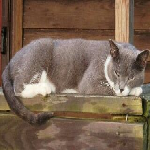

In [29]:
img_path = fnames[40]

img = image.load_img(img_path, target_size=(150, 150))

x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
img

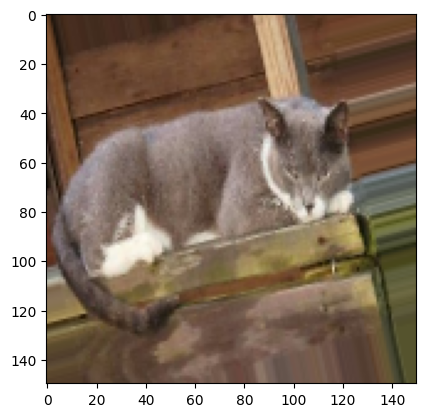

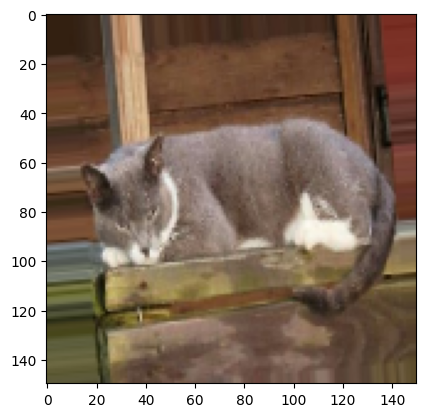

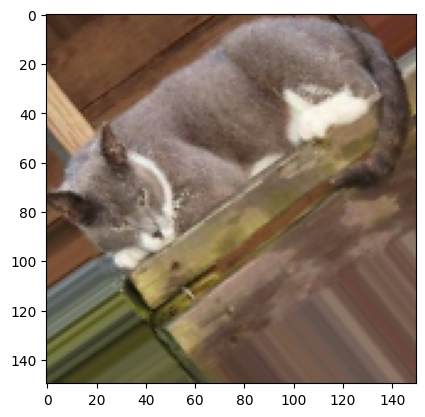

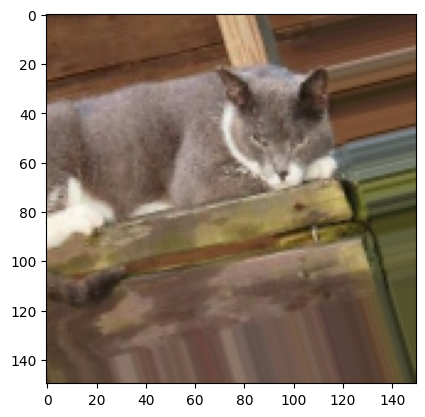

In [31]:
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 4 == 0:
        break
plt.show()

In [32]:
from keras import layers
from keras import models
from keras import optimizers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

C:\Users\aydin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

history = model.fit(train_generator, epochs=100, validation_data=validation_generator)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - acc: 0.5100 - loss: 0.6937 - val_acc: 0.4960 - val_loss: 0.6942
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - acc: 0.5335 - loss: 0.6891 - val_acc: 0.5840 - val_loss: 0.6840
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 981ms/step - acc: 0.5425 - loss: 0.6866 - val_acc: 0.5030 - val_loss: 0.6892
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 61s 959ms/step - acc: 0.5660 - loss: 0.6801 - val_acc: 0.5310 - val_loss: 0.6833
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 897ms/step - acc: 0.5790 - loss: 0.6744 - val_acc: 0.5710 - val_loss: 0.6709
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 903ms/step - acc: 0.5945 - loss: 0.6639 - val_acc: 0.6000 - val_loss: 0.6547
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 59s 934ms/step - acc: 0.5805 - loss: 0.6683 - val_acc: 0.6260 - val_loss: 0.6460
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 58s 918ms/step - acc: 0.5915 - loss: 0.6660